<a href="https://colab.research.google.com/github/LAOLIVEIRA1972/PUC_MVP_AnaliseDados/blob/main/mvp_Analise_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Leandro Alexandre de Oliveira

**Matrícula:** 4052025001609

**Data:** 08/04/2026

**Dataset:** [dataset_plataformas](https://raw.githubusercontent.com/LAOLIVEIRA1972/PUC_MVP_AnaliseDados/main/dataset_plataformas.xlsx)


# 1- Descrição do Problema
---



## 1.1- Objetivo

O dataset utilizado neste trabalho é um conjunto de dados multivariado composto por informações referentes a paradas programadas de plataformas petrolíferas de uma empresa específica do setor.

O objetivo principal deste projeto é estimar a duração dessas paradas programadas com base nas características associadas a cada ocorrência.

**Objetivos específicos**

1. **Melhor previsibilidade**: fornecer uma ferramenta que auxilia na previsibilidade de duração de paradas programadas, proporcionando maior confiabilidade e planejamento antecipado.

2. **Suporte à tomada de decisão**: fornecer suporte aos profissionais responsáveis pela programação das paradas, auxliando a determinar o melhor momento de realização do evento. Isto possibilita uma análise mais robusta sobre alocação de recursos, condições ambientais (tempo e mar), disponibilidade de sondas, entre outros fatores relevantes.

3. **Automatização**: automatizar o processo de cálculo da duração das paradas, tornando o processo mais ágil e eficiente em comparação com métodos manuais, além de reduzir erros e aumentar a consistência das análises.



## 1.2- Hipóteses do Problema

A parada programada de uma plataforma petrolífera é um processo planejado e controlado em que a produção de petróleo é reduzida de forma parcial ou integral, para realizar manutenções preventivas, corretivas, inspeções regulamentares e melhorias operacionais.

Esse evento deve ser cuidadosamente planejado para otimizar sua duração, minimizando o impacto na perda de volume produzido e, consequentemente, na receita da empresa.

A duração de uma parada programada depende da complexidade e extensão da manutenção necessária, podendo variar de alguns dias a algumas semanas, ou até meses.

Neste projeto, serão analisados alguns dos principais fatores que podem influenciar a duração das paradas programadas, tais como: idade da plataforma, tipo de plataforma, propriedade (própria ou afretada), lâmina d’água, bacia de operação, tipo de operação (produção ou injeção) e restrição à queima de gás.

As hipóteses investigadas neste estudo são as seguintes:

1. **Determinados tipos de plataformas estão associados a paradas programadas de maior duração?**

2. **Existe correlação entre a idade da plataforma e a duração da parada programada, considerando que equipamentos mais antigos podem demandar maior atenção de manutenção?**

3. **Paradas realizadas em plataformas afretadas apresentam menor duração (maior otimização) do que aquelas realizadas em plataformas próprias?**

4. **Considerando que operações em maiores profundidades tendem a ser mais complexas, as paradas programadas em lâminas d’água rasas geralmente apresentam menor duração?**

5. **O tipo de operação (produção ou injeção) e a existência de restrição à queima de gás durante a parada influenciam a sua duração?**





## 1.3- Tipo de Problema

Dado um conjunto de características referentes a paradas programadas em plataformas petrolíferas, o objetivo é prever a duração, em número de dias, de cada ocorrência. Como a variável de interesse é uma medida quantitativa contínua, o problema é caracterizado como um problema de **regressão supervisionada**.

## 1.4- Seleção de Dados

Foram consideradas apenas paradas programadas, ou seja, aquelas previstas no Plano de Negócios da empresa. Paradas não programadas não foram incluídas na análise, como, por exemplo, aquelas decorrentes de interdições por órgãos reguladores, uma vez que esses eventos geralmente não apresentam previsibilidade quanto à sua periodicidade.

Foram coletadas informações sobre paradas programadas a partir de 2010, conforme a disponibilidade no banco de dados da empresa. Além disso, foram selecionadas apenas paradas realizadas em bacias sedimentares da região Sudeste, visto que plataformas localizadas em outras regiões encontram-se em processo de descomissionamento ou desinvestimento. Dessa forma, buscou-se evitar possíveis distorções nos resultados da análise.

Por questões de segurança e confidencialidade, foi realizada a substituição dos dados originais por valores alterados, preservando-se, contudo, as características estatísticas e estruturais do conjunto de dados.

## 1.5- Descrição do Dataset

O dataset é composto por mais de 600 registros com dados referentes a paradas programadas de uma Empresa do setor de petróleo, com as seguintes informações:

- ***Id_Parada***: identificador da ocorrência da parada programada.
- ***Plataforma***: sigla da plataforma.
- ***Tipo***: tipo da plataforma (FPSO, FPU, Fixa, Semi-submersível, TWLP).
- ***Propriedade***: indica se a plataforma é própria ou afretada.
- ***LDA***: lâmina d'água onde a plataforma opera. Pode ser Rasa (até 300m), Profunda (de 300 a 1.500m) ou Ultraprofunda (acima de 1.500m), conforme classificação da ANP (Agência Nacional do Petróleo, Gás Natural e Biocombustíveis).
- ***Bacia***: bacia sedimentar onde a plataforma opera.
- ***Restrição de queima***: indica se a parada ocasionará restrição na queima de gás da plataforma.
- ***Tipo operação***: indica se o impacto da parada será na operação de produção ou injeção da plataforma.
- ***Idade***: idade em anos da plataforma no momento da parada.
- ***Duração***: duração da parada em dias. Corresponde a variável alvo (target) para predição.

Para efeito de apuração dos atributos **Idade** e **Duração**, foi considerada como data de corte **31/12/2025**.

Observação: este dataset é o mesmo empregado no MVP desenvolvido na disciplina de *Machine Learning*.

# 2- Importação das Bibliotecas Necessárias e Carga de Dados
---

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset contendo informações de paradas de plataformas petrólíferas.

In [1]:
import pandas as pd # biblioteca pandas
import numpy as np # biblioteca numpy
import matplotlib.pyplot as plt # criação e visualização de dados
import seaborn as sns # criação de gráficos estatísticos para análise exploratória de dados
from sklearn.model_selection import train_test_split # para particionar em bases de treino e teste (holdout)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder # algoritmos para transformação e padronização dos dados

In [2]:
# Informa a URL de importação do dataset (usando o link raw para o arquivo no GitHub)
url = "https://raw.githubusercontent.com/LAOLIVEIRA1972/PUC_MVP_AnaliseDados/main/dataset_plataformas.xlsx"

# Leitura do arquivo
dataset = pd.read_excel(url)

# 3- Análise de Dados
---
Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset de paradas de plataformas, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## 3.1- Informações Gerais



### 3.1.1- Total de Instâncias e Tipos de Atributos

In [3]:
# Verificando as dimensões do dataset
print(f"Dimensões do dataset: {dataset.shape}")

# Verificando os tipos de dados
print("\nTipos de dados por coluna:")
print(dataset.info())


Dimensões do dataset: (611, 10)

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 611 entries, 0 to 610
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID_PARADA         611 non-null    object
 1   PLATAFORMA        611 non-null    object
 2   TIPO              611 non-null    object
 3   PROPRIEDADE       611 non-null    object
 4   LDA               611 non-null    object
 5   BACIA             611 non-null    object
 6   RESTRICAO_QUEIMA  611 non-null    object
 7   TIPO_OPERACAO     611 non-null    object
 8   IDADE             611 non-null    int64 
 9   DURAÇÃO           611 non-null    int64 
dtypes: int64(2), object(8)
memory usage: 47.9+ KB
None


O dataset que será trabalhado possui 611 instâncias e 10 colunas. Temos 8 variáveis categóricas e 2 do tipo *int*.

### 3.1.2- Verificação de Valores Nulos

In [4]:
# Verificando a quantidade de nulos
print("\nAnálise de quantidade de nulos:")
dataset.isnull().sum()


Análise de quantidade de nulos:


,0
ID_PARADA,0
PLATAFORMA,0
TIPO,0
PROPRIEDADE,0
LDA,0
BACIA,0
RESTRICAO_QUEIMA,0
TIPO_OPERACAO,0
IDADE,0
DURAÇÃO,0


Observa-se a ausência de valores nulos em todas as variáveis do dataset.

A inexistência de valores faltantes pode ser atribuída à elevada sensibilidade dessas informações no contexto do cálculo de perdas de produção, sejam elas totais ou parciais. Nesse sentido, os dados são submetidos a um rigoroso processo de validação no sistema responsável pelo registro das paradas programadas, assegurando sua integridade e consistência.

### 3.1.3- Verificação de Registros Duplicados

In [5]:
# Verificando a existência de registros duplicados no dataset
print(f"Quantidade de registros duplicados: {dataset.duplicated().sum()}")

Quantidade de registros duplicados: 0


Não foram encontrados registros duplicados.


###3.1.4- Verificação das Primeiras Linhas do Dataset

In [6]:
# Verificando as dez primeiras linhas do dataset
dataset.head(10)

,ID_PARADA,PLATAFORMA,TIPO,PROPRIEDADE,LDA,BACIA,RESTRICAO_QUEIMA,TIPO_OPERACAO,IDADE,DURAÇÃO
0,PP12601,PA04,FPSO,Afretado,P,B1,NÃO,Produção,3,9
1,PP12602,PA05,FPSO,Afretado,P,B1,NÃO,Produção,3,14
2,PP12603,PA05,FPSO,Afretado,P,B1,NÃO,Injeção,3,13
3,PP12604,PA09,FPSO,Afretado,P,B1,NÃO,Produção,4,14
4,PP12605,PA09,FPSO,Afretado,P,B1,NÃO,Produção,6,25
5,PP12606,PA09,FPSO,Afretado,P,B1,NÃO,Produção,8,12
6,PP12607,PA21,FPSO,Afretado,P,B1,NÃO,Produção,11,2
7,PP12608,PA21,FPSO,Afretado,P,B1,NÃO,Produção,11,2
8,PP12609,PA21,FPSO,Afretado,P,B1,NÃO,Produção,11,5
9,PP12610,PA22,FPSO,Afretado,P,B1,NÃO,Produção,6,4


A análise das primeiras linhas do dataset não evidenciou anormalidades.

A verificação das linhas 6 e 7 pode, inicialmente, sugerir duplicidade de registros. Contudo, deve-se considerar a possibilidade de múltiplas paradas programadas para uma mesma plataforma no mesmo ano, estratégia adotada com o objetivo de otimizar as perdas de produção, por meio da realização de manutenções em eventos de menor duração.

No caso das linhas 6 e 7, apesar da similaridade entre os atributos, as ocorrências são distintas, conforme evidenciado pela coluna **ID_PARADA** (identificador de cada ocorrência de parada programada).

###3.1.5- Verificação das Últimas Linhas do Dataset

In [7]:
# Verificando as últimas linhas do dataset para atestar que o dataset foi integralmente carregado
dataset.tail(10)

,ID_PARADA,PLATAFORMA,TIPO,PROPRIEDADE,LDA,BACIA,RESTRICAO_QUEIMA,TIPO_OPERACAO,IDADE,DURAÇÃO
601,PP13202,PA23,FPSO,Afretado,U,B2,NÃO,Produção,4,50
602,PP13203,PA23,FPSO,Afretado,U,B2,NÃO,Produção,5,2
603,PP13204,PA23,FPSO,Afretado,U,B2,NÃO,Produção,6,26
604,PP13205,PA23,FPSO,Afretado,U,B2,NÃO,Produção,6,3
605,PP13206,PA23,FPSO,Afretado,U,B2,NÃO,Produção,7,1
606,PP13207,PA23,FPSO,Afretado,U,B2,NÃO,Produção,8,14
607,PP13208,PA23,FPSO,Afretado,U,B2,NÃO,Produção,8,15
608,PP13209,PA23,FPSO,Afretado,U,B2,SIM,Produção,9,4
609,PP13210,PA25,FPSO,Afretado,U,B2,NÃO,Produção,3,7
610,PP13211,PA25,FPSO,Afretado,U,B2,SIM,Produção,3,4


A exibição das últimas linhas indica que o dataset foi carregado integralmente. O último registro apresenta o índice 610, considerando que a contagem se inicia em 0, o que confirma que os 611 registros foram devidamente carregados.

## 3.2- Estatísticas Descritivas

Resumo estatístico das variáveis contínuas do dataset, incluindo média, desvio padrão, mínimo, máximo e quartis.. Para o dataset deste trabalho, a análise será realizada nos atributos **Idade** e **Duração**.


In [10]:
# Estatísticas descritivas básicas do dataset nos atrbutos Idade e Duração
dataset.describe()

,IDADE,DURAÇÃO
count,611.000000,611.000000
mean,12.060556,19.908347
std,8.292873,26.975486
min,1.000000,1.000000
25%,6.000000,5.000000
50%,9.000000,13.000000
75%,15.500000,25.000000
max,38.000000,377.000000


**Duração**: Trata-se de um conjunto de ocorrências de paradas programadas que apresentam, em média, duração de 20 dias. A análise dos valores mínimo, máximo e dos quartis indica que as durações estão distribuídas ao longo de uma ampla faixa, afastando-se da média. Isso sugere a existência de elevada variabilidade no tempo de duração desses eventos.

**Idade**: Observa-se uma ampla faixa etária das plataformas, variando desde o primeiro ano de operação até 38 anos. Essa dispersão é evidenciada pelos valores mínimo e máximo, bem como pelo desvio padrão, indicando heterogeneidade na idade dos ativos analisados.

##3.3- Visualizações e Análise de Correlações

### 3.3.1- Média e Desvio Padrão de Duração de Paradas por Tipo de Plataforma

A **média** é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (*outliers*).

O **desvio padrão** é uma medida de dispersão que quantifica a variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

Como estratégia para avaliação da primeira hipótese deste estudo — que visa verificar se **determinados tipos de plataformas estão associados a paradas programadas de maior duração** — adotou-se o uso de gráfico de barras com linhas de erro (*error bars*) para apresentar o desvio padrão, pois ele comunica duas informações essenciais ao mesmo tempo: a média (valor central) e a variabilidade (desvio padrão). As linhas de erro sobre as barras representam a dispersão dos dados em torno da média, facilitando a interpretação da consistência das observações.

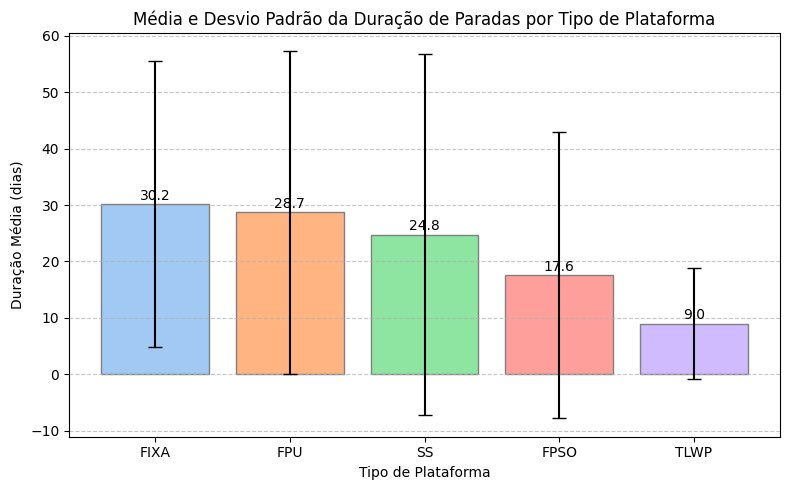

In [11]:
# Calcular média e desvio padrão por plataforma
dp_dataset = dataset.groupby('TIPO')['DURAÇÃO'].agg(['mean', 'std'])

# Ordenar do maior para o menor pela média
dp_dataset = dp_dataset.sort_values(by='mean', ascending=False)

# Paleta de cores personalizada
cores = sns.color_palette("pastel", len(dp_dataset))

# Criar gráfico de barras
plt.figure(figsize=(8,5))
bars = plt.bar(dp_dataset.index,
               dp_dataset['mean'],
               yerr=dp_dataset['std'],
               capsize=5,
               color=cores,
               edgecolor='gray')

# Adicionar valores das médias sobre as barras
for bar in bars:
    altura = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, altura + 0.2, f'{altura:.1f}',
             ha='center', va='bottom', fontsize=10)

# configra os eixos para exibir o eixo Y com tracejado
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Customização
plt.title('Média e Desvio Padrão da Duração de Paradas por Tipo de Plataforma')
plt.xlabel('Tipo de Plataforma')
plt.ylabel('Duração Média (dias)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

A análise do gráfico das médias de duração, em dias, por tipo de plataforma indica que plataformas do tipo fixa apresentam maior duração das paradas em relação aos demais tipos. Observa-se, ainda, que as plataformas do tipo FPU (unidade flutuante de produção, sem armazenamento) exibem resultados bastante semelhantes entre si, sugerindo menor diferenciação interna nesse grupo.

Tal comportamento é consistente com as características operacionais dessas unidades, uma vez que plataformas fixas — geralmente empregadas nos estágios iniciais dos projetos de produção marítima, em lâminas d’água mais rasas e, em sua maioria, mais antigas — tendem a demandar tempos mais elevados de manutenção.

Os desvios padrão apresentados no gráfico indicam que as durações das paradas, para cada tipo de plataforma, estão distribuídas ao longo de uma ampla faixa de valores, afastando-se da média, o que evidencia elevada variabilidade nos dados.

Dessa forma, embora os resultados descritivos apontem para uma possível associação entre o tipo de plataforma e a duração das paradas programadas, a elevada dispersão observada sugere cautela na interpretação, indicando a necessidade de análises estatísticas adicionais para verificar a significância dessa relação.

### 3.3.2 - Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (*outliers*). O **histograma** é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

#### 3.3.2.1- Duração das paradas


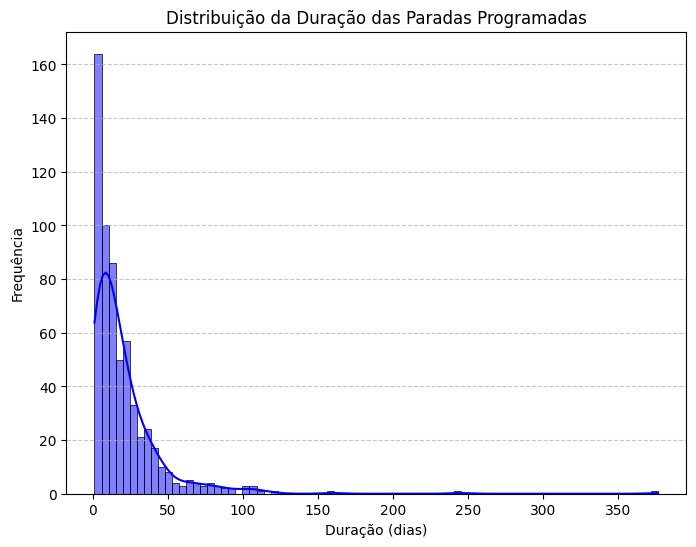

In [ ]:
# Histograma para a distribuição da duração de paradas programadas para análise da variável alvo
plt.figure(figsize=(8, 6))

# plota o gráfico
sns.histplot(dataset['DURAÇÃO'], kde=True, color="blue")

# configra os eixos para exibir o eixo Y com tracejado
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Títulos
plt.title('Distribuição da Duração das Paradas Programadas')
plt.xlabel('Duração (dias)')
plt.ylabel('Frequência')
plt.show()

A análise do histograma da distribuição da duração, em dias, das paradas programadas em plataformas petrolíferas evidencia a presença de valores extremos elevados, os quais deslocam a massa de dados para a esquerda, caracterizando uma distribuição com assimetria à direita.

Observa-se que a maior parte das durações se concentra em valores baixos ou moderados, enquanto poucos eventos apresentam alta magnitude, resultando em paradas mais prolongadas e de maior impacto operacional.

Diante desse comportamento, torna-se necessária a aplicação de técnicas de pré-processamento para o tratamento de potenciais *outliers*, a fim de mitigar seus efeitos sobre as análises estatísticas e modelos preditivos.

#### 3.3.3.2- Idade das plataformas

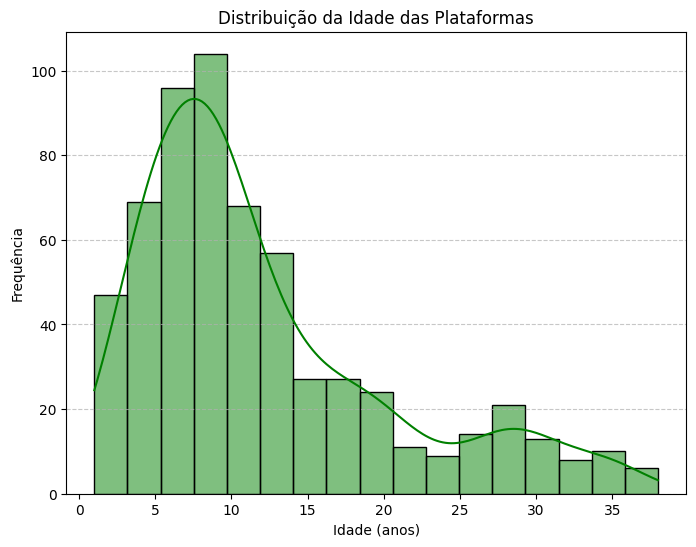

In [12]:
# Histograma para a distribuição da idade das plataformas
plt.figure(figsize=(8, 6))

# plota o gráfico
sns.histplot(dataset['IDADE'], kde=True, color="green")

# configra os eixos para exibir o eixo Y com tracejado
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Títulos
plt.title('Distribuição da Idade das Plataformas')
plt.xlabel('Idade (anos)')
plt.ylabel('Frequência')
plt.show()

O histograma mostra a distribuição da idade das plataformas durante as ocorrências de paradas programadas. Observa-se uma concentração maior de dados à direita, caracterizando uma distribuição assimétrica à direita (positivamente enviesada).

A maior frequência de idades está concentrada entre 5 e 10 anos, indicando que a maioria das paradas programadas ocorre em plataformas relativamente jovens. Essa informação pode ser utilizada para planejamento de cronogramas de manutenção, permitindo antecipar paradas e otimizar recursos, inclusive em projetos de plataformas recém-instaladas.




### 3.3.3- Matriz de Correlação

A **matriz de correlação** é uma ferramenta utilizada para medir a força e a direção da relação linear entre atributos numéricos de um conjunto de dados. Valores próximos de 1 indicam forte correlação positiva, enquanto valores próximos de -1 indicam forte correlação negativa; valores próximos de 0, por sua vez, sugerem ausência de correlação linear.

Para a análise da segunda hipótese deste trabalho — que busca **verificar a existência de correlação entre a idade da plataforma e a duração das paradas programadas, considerando que equipamentos mais antigos podem demandar maior atenção de manutenção** — será construída uma matriz de correlação entre os atributos **Idade** e **Duração**.

In [15]:
# Matriz de correlação
print("\nMatriz de Correlação:")

# seleciona os atributos idade e duração
atributos_selecionados = ['IDADE', 'DURAÇÃO']
dataset_selecionados = dataset[atributos_selecionados]
dataset_selecionados.corr()


Matriz de Correlação:


,IDADE,DURAÇÃO
IDADE,1.000000,0.238601
DURAÇÃO,0.238601,1.000000


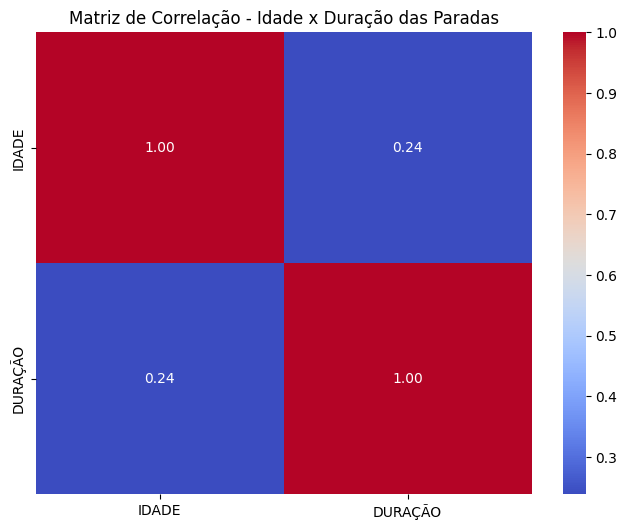

In [16]:
# mapa de calor das variáveis numéricas
plt.figure(figsize=(8, 6))

sns.heatmap(dataset_selecionados.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação - Idade x Duração das Paradas')
plt.show()

A interpretação da matriz de correlação permite avaliar a intensidade e a direção da relação entre as variáveis analisadas. Uma correlação positiva significativa indicaria que plataformas mais antigas tendem a apresentar paradas programadas mais longas, corroborando a hipótese proposta.

Por outro lado, uma correlação fraca ou próxima de zero sugeriria que a idade da plataforma, isoladamente, não exerce influência relevante sobre a duração das paradas, indicando a possível atuação de outros fatores, como o tipo de unidade ou as condições operacionais.

No presente estudo, o coeficiente de correlação obtido foi de **0,24**, evidenciando uma relação linear positiva fraca entre a idade da plataforma e a duração das paradas programadas. Isso indica que plataformas mais antigas tendem, em média, a apresentar paradas ligeiramente mais longas, mas o efeito é pouco intenso.

Dessa forma, a hipótese de que a idade das plataformas influencia significativamente a duração das paradas é parcialmente suportada pelos dados. A correlação fraca sugere que fatores adicionais, como o tipo de plataforma e as condições operacionais, por exemplo, provavelmente exercem influência mais relevante sobre a duração das paradas.

### 3.3.4- Boxplot

Para entender as diferenças nas durações das paradas programadas, é importante analisar como os valores se comportam quando agrupados pelas principais características de cada ocorrência.

Essa abordagem permite comparar métricas estatísticas, como média, mediana e desvio padrão, de cada grupo, além de visualizar suas distribuições por meio de boxplots, facilitando a identificação de padrões, variações e possíveis outliers.

Para análise das demais hipóteses deste trabalho, listadas abaixo, serão elaborados gráficos do tipo Boxpot:
- **Paradas realizadas em plataformas afretadas apresentam menor duração (maior otimização) do que aquelas realizadas em plataformas próprias?**
- **Considerando que operações em maiores profundidades tendem a ser mais complexas, as paradas programadas em lâminas d’água rasas geralmente apresentam menor duração?**
- **O tipo de operação (produção ou injeção) e a existência de restrição à queima de gás durante a parada influenciam a sua duração?**

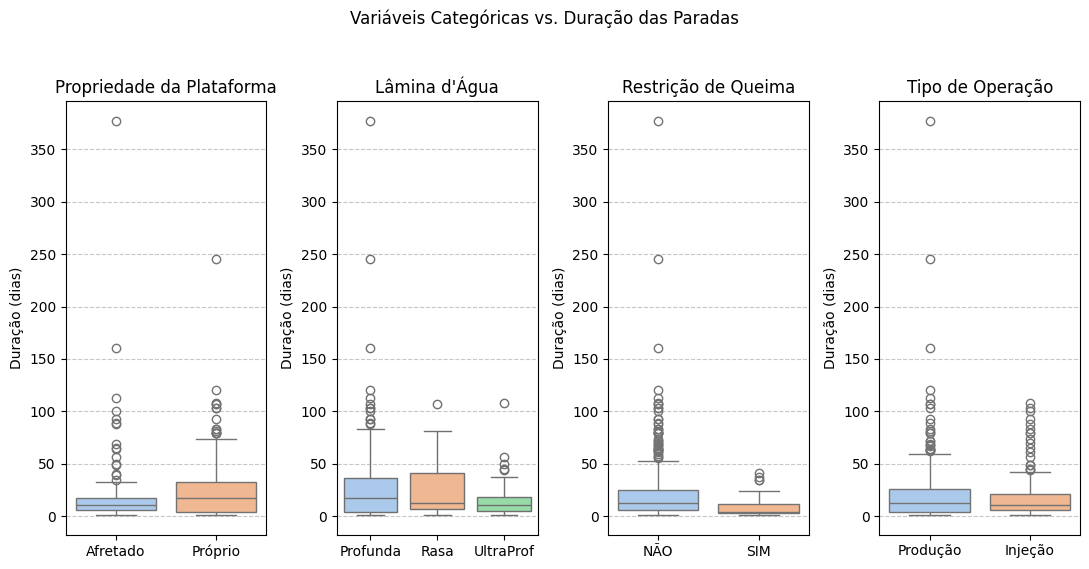

In [17]:
# Configuração e título
fig, axes = plt.subplots(1, 4, figsize=(11, 6))
plt.suptitle('Variáveis Categóricas vs. Duração das Paradas')

# Boxplot 1: Propriedade da plataforma
sns.boxplot(ax=axes[0], x='PROPRIEDADE', y='DURAÇÃO', hue='PROPRIEDADE', data=dataset, palette='pastel')
axes[0].set_xlabel('')
axes[0].set_ylabel('Duração (dias)')
axes[0].set_title('Propriedade da Plataforma')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Boxplot 2: Lâmina d'Água (LDA)
sns.boxplot(ax=axes[1], x='LDA', y='DURAÇÃO', hue='LDA', data=dataset, palette='pastel')
axes[1].set_xlabel('')
axes[1].set_ylabel('Duração (dias)')
axes[1].set_title('Lâmina d\'Água')
axes[1].set_xticks(['P', 'R', 'U'])
axes[1].set_xticklabels(['Profunda', 'Rasa', 'UltraProf'])
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Boxplot 3: Restrição de Queima
sns.boxplot(ax=axes[2], x='RESTRICAO_QUEIMA', y='DURAÇÃO', hue='RESTRICAO_QUEIMA', data=dataset, palette='pastel')
axes[2].set_xlabel('')
axes[2].set_ylabel('Duração (dias)')
axes[2].set_title('Restrição de Queima')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Boxplot 4: Tipo de Operação
sns.boxplot(ax=axes[3], x='TIPO_OPERACAO', y='DURAÇÃO', hue='TIPO_OPERACAO', data=dataset, palette='pastel')
axes[3].set_xlabel('')
axes[3].set_ylabel('Duração (dias)')
axes[3].set_title('Tipo de Operação')
axes[3].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.show()

A análise dos gráficos indica que as durações das paradas apresentam elevada variabilidade, com valores distribuídos em uma ampla faixa e presença de extremos significativamente acima da média. Ainda assim, a maior concentração das observações ocorre em níveis baixos a moderados.

**Propriedade da plataforma**: plataformas **Próprias** apresentam uma mediana de duração maior em comparação com plataformas **Afretadas**, indicando que, em geral, suas operações tendem a durar mais. Além disso, as plataformas **Próprias** possuem maior dispersão, com uma caixa mais ampla e maior variação nos dados, sugerindo menor previsibilidade. Já as **Afretadas** apresentam menor variabilidade, com durações mais concentradas. Outro ponto importante é a presença de *outliers* em ambas as categorias, mas com destaque para **Afretadas**, que apresenta o valor mais extremo (acima de 350 dias), indicando que, embora raros, eventos muito longos também podem ocorrer nesse grupo

**Lâmina d’água**: operações em águas **Profundas** apresentam a maior mediana de duração, indicando que estes eventos tendem a durar mais, enquanto operações em águas **Ultra-profundas** possuem a menor mediana. Em termos de variabilidade, a categoria **Profunda** se destaca por ter maior dispersão e diversos valores extremos, incluindo os maiores tempos observados, o que sugere maior imprevisibilidade. Já **Ultra-profunda** apresenta menor dispersão e maior consistência nos dados. Operações em águas **Rasas** apresentam mediana intermediária entre as categorias e dispersão moderada.

**Restrição de queima de gás**: as paradas **sem restrição de queima de gás** apresentam mediana ligeiramente superior às paradas **com restrição**, além de maior variabilidade, evidenciada por um intervalo interquartil mais amplo. Observa-se também que a maior parte dos valores extremos está concentrada na categoria **sem restrição**, incluindo os maiores valores observados. Por outro lado, paradas **com restrição** exibem menor dispersão e menor ocorrência de *outliers*.

**Tipo de operação (produção ou injeção)**: duas categorias apresentam medianas próximas, sugerindo que a duração típica das operações é semelhante entre elas. No entanto, observa-se uma diferença significativa na dispersão dos dados. A operação de **Produção** apresenta maior variabilidade, evidenciada por uma caixa (intervalo interquartil) mais ampla e maior extensão dos valores. Além disso, concentra uma quantidade significativa de *outliers*, incluindo valores extremamente elevados, o que indica a ocorrência de operações com duração muito acima do padrão. Por outro lado, a operação de **Injeção** apresenta menor dispersão e menor presença de valores extremos, caracterizando um comportamento mais estável e previsível.

Em síntese, os resultados sugerem que diferentes características operacionais influenciam principalmente a variabilidade e a presença de valores extremos nas durações das paradas programadas, mesmo quando as medianas permanecem relativamente estáveis entre os grupos.


# 4- Pré-Processamento de Dados
---

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [18]:
# cópia do dataset original para realização do pré-processamento
dataset_proc = dataset.copy()

##4.1- Limpeza dos dados

###4.1.1- Tratamento de Valores Ausentes (*Missing Values*)

O dataset não possui valores nulos.

Embora o tratamento de dados ausentes constitua uma etapa fundamental em análises estatísticas e de ciência de dados — podendo envolver técnicas de imputação (como média, mediana ou moda) ou a exclusão de registros —, tal procedimento não se fez necessário neste estudo.


###4.1.2- Tratamento de *Outliers*

Embora tenha sido identificada a presença de diversos *outliers*, especialmente na variável **Duração**, não se tratam de erros de digitação ou de medição. Pelo contrário, são observações válidas e potencialmente informativas para o modelo de predição. Dessa forma, optou-se estrategicamente por não realizar qualquer tipo de tratamento nesses valores, preservando os dados em sua forma original.

##4.2- *Feature Engineering* e *Feature Selection*

A coluna **ID_PARADA** consiste em um identificador único atribuído a cada ocorrência de parada programada pelo sistema responsável pelo processamento dos eventos. No contexto deste estudo, essa variável não apresenta relevância para a predição da duração das paradas, uma vez que não carrega informação explicativa sobre o fenômeno analisado. Por essa razão, optou-se por sua exclusão do dataset.

In [19]:
# Remoção da coluna ID_PARADA
dataset_proc.drop('ID_PARADA', axis=1, inplace=True)
# exibe as primeiras linhas para verificar a exclusão da coluna
dataset_proc.head()

,PLATAFORMA,TIPO,PROPRIEDADE,LDA,BACIA,RESTRICAO_QUEIMA,TIPO_OPERACAO,IDADE,DURAÇÃO
0,PA04,FPSO,Afretado,P,B1,NÃO,Produção,3,9
1,PA05,FPSO,Afretado,P,B1,NÃO,Produção,3,14
2,PA05,FPSO,Afretado,P,B1,NÃO,Injeção,3,13
3,PA09,FPSO,Afretado,P,B1,NÃO,Produção,4,14
4,PA09,FPSO,Afretado,P,B1,NÃO,Produção,6,25


Como os modelos de *Machine Learning* são funções matemáticas que operam sobre valores numéricos, é fundamental converter todas as variáveis categóricas para um formato adequado. Nesse contexto, será utilizada a técnica de ***dummy encoding*** para transformar as variáveis categóricas **PROPRIEDADE**, **LDA**, **BACIA**, **RESTRIÇÃO_QUEIMA** e **TIPO_OPERACAO**. Essa abordagem consiste na criação de novas colunas binárias para cada categoria, evitando a introdução de uma relação ordinal artificial que poderia induzir o modelo a interpretações equivocadas.

Para as variáveis **TIPO** e **PLATAFORMA**, será aplicada a técnica de ***label encoding***, que consiste na atribuição de um valor numérico inteiro para cada categoria distinta. Essa escolha se justifica pelo elevado número de categorias presentes nessas variáveis, o que tornaria o uso de ***dummy encoding*** pouco eficiente devido ao aumento significativo da dimensionalidade do conjunto de dados. Dessa forma, o ***label encoding*** permite uma representação mais compacta, mantendo a viabilidade computacional do modelo.

In [20]:
# aplicação do dummy encoding para transformação de PROPRIEDADE, LDA,
# BACIA, TIPO_OPERACAO e RESTRICAO_QUEIMA em variáveis binárias
dataset_proc = pd.get_dummies(dataset_proc, columns=['PROPRIEDADE', 'LDA', 'BACIA', 'TIPO_OPERACAO', 'RESTRICAO_QUEIMA'], drop_first=True, dtype=int)

# aplicação do label encoded para transformar PLATFORMA e TIPO de categórica em numérica
dataset_proc['PLATAFORMA'] = LabelEncoder().fit_transform(dataset_proc['PLATAFORMA'])
dataset_proc['TIPO'] = LabelEncoder().fit_transform(dataset_proc['TIPO'])

# exibe as primeiras linhas para verificar as transformações
dataset_proc.head()



,PLATAFORMA,TIPO,IDADE,DURAÇÃO,PROPRIEDADE_Próprio,LDA_R,LDA_U,BACIA_B2,TIPO_OPERACAO_Produção,RESTRICAO_QUEIMA_SIM
0,3,1,3,9,0,0,0,0,1,0
1,4,1,3,14,0,0,0,0,1,0
2,4,1,3,13,0,0,0,0,0,0
3,8,1,4,14,0,0,0,0,1,0
4,8,1,6,25,0,0,0,0,1,0


In [21]:
# Verificando dimensões do dataset
dataset_proc.shape


(611, 10)

Podemos verificar que a dimensão do dataset foi mantida em relação à base original. Embora a aplicação da técnica de ***dummy encoding*** tenda a aumentar o número de colunas, na prática apenas uma variável resultou em acréscimo de dimensionalidade, no caso **LDA**. Esse aumento foi compensado pela remoção da coluna **ID_PARADA**, de modo que o conjunto de dados final preserva a mesma dimensionalidade do original.

##4.3- Separação do Dataset entre Treino e Teste

Etapa fundamental em *Machine Learning*, que consiste na divisão do dataset em dois subconjuntos: um conjunto de treinamento, geralmente maior, utilizado para a construção do modelo, e um conjunto de teste, geralmente menor, destinado à avaliação do modelo treinado. Essa abordagem contribui para uma estimativa mais confiável da capacidade de generalização do modelo.

Será aplicada a técnica do ***holdout*** para efetuar a divisão do dataset original em bases de treino (80%) e de teste (20%).

In [22]:
# separação dos atributos da target, no caso a variável DURAÇÃO
X = dataset_proc.iloc[:, 0:9]
y= dataset_proc['DURAÇÃO']

# Separação em bases de treino e teste (holdout)
# faz a divisão em bases de treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.20, random_state=42)

# exibe as dimensões dos conjuntos de dads gerados
print(f"Dimensões de X_treino: {X_treino.shape}")
print(f"Dimensões de X_teste: {X_teste.shape}")
print(f"Dimensões de y_treino: {y_treino.shape}")
print(f"Dimensões de y_teste: {y_teste.shape}")


Dimensões de X_treino: (488, 9)
Dimensões de X_teste: (123, 9)
Dimensões de y_treino: (488,)
Dimensões de y_teste: (123,)


O resultado da divisão do dataset indica que 488 instâncias foram destinadas à base de treino e 123 à base de teste, correspondendo às proporções de 80% e 20%, respectivamente.

## 4.4- Normalização e Padronização

A **normalização** escala os dados para um intervalo fixo, geralmente entre 0 e 1. Ela é especialmente útil quando é necessário garantir que todas as variáveis estejam na mesma escala, o que pode ser importante para algoritmos que dependem de distâncias ou que assumem magnitudes semelhantes entre as características.

Já a **padronização** transforma os dados de forma que passem a ter média 0 e desvio padrão 1. Esse tipo de transformação é mais adequado para algoritmos que são sensíveis à variância dos dados, como SVMs, regressões lineares e redes neurais.

Além disso, a padronização tende a ser mais robusta do que a normalização na presença de valores extremos (*outliers*), pois não depende diretamente dos valores mínimo e máximo da distribuição.

Dessa forma, foi optada pela padronização, devido à existência de *outliers* e às distribuições assimétricas.



In [23]:
# Aplicação da padronização para as variáveis numéricas do dataset que serão utilizadas como features para o modelo (neste caso, apenas 'IDADE')

# Salvando a coluna original antes de padronizar
idade_original = X_treino['IDADE'].copy()

# Identificação das colunas numéricas contínuas para escalonar, neste caso, apenas 'IDADE'
numericas_to_scale = ['IDADE']

# Inicialização e aplicação do StandardScaler APENAS nas colunas numéricas
scaler = StandardScaler()

# Aplica fit_transform nas colunas numéricas do conjunto de TREINO
# O uso de .copy() é uma boa prática para evitar SettingWithCopyWarning
X_treino[numericas_to_scale] = scaler.fit_transform(X_treino[numericas_to_scale]).copy()

# Aplica APENAS transform (com base nas estatísticas aprendidas em X_treino) nas mesmas colunas do conjunto de TESTE
X_teste[numericas_to_scale] = scaler.transform(X_teste[numericas_to_scale]).copy()

# X_treino e X_teste têm as colunas binárias inalteradas e a coluna 'IDADE' padronizada.
print("X_treino (primeiras 5 linhas) após padronização da Idade:")
display(X_treino.head())
print("\nX_teste (primeiras 5 linhas) após padronização da Idade:")
display(X_teste.head())




X_treino (primeiras 5 linhas) após padronização da Idade:


,PLATAFORMA,TIPO,IDADE,DURAÇÃO,PROPRIEDADE_Próprio,LDA_R,LDA_U,BACIA_B2,TIPO_OPERACAO_Produção
561,46,3,-0.459923,11,1,0,1,0,0
287,13,1,-0.818076,7,0,0,1,1,0
322,14,1,0.136998,2,0,0,1,1,1
132,44,2,-0.698691,18,1,0,0,0,1
174,68,0,1.927762,12,1,1,0,0,1



X_teste (primeiras 5 linhas) após padronização da Idade:


,PLATAFORMA,TIPO,IDADE,DURAÇÃO,PROPRIEDADE_Próprio,LDA_R,LDA_U,BACIA_B2,TIPO_OPERACAO_Produção
81,37,1,0.375767,1,1,0,0,0,1
218,7,1,0.136998,16,0,0,1,1,1
55,30,3,1.330841,2,1,0,0,0,1
599,19,1,-1.056844,20,0,0,1,1,1
264,12,1,-0.937460,13,0,0,1,1,1


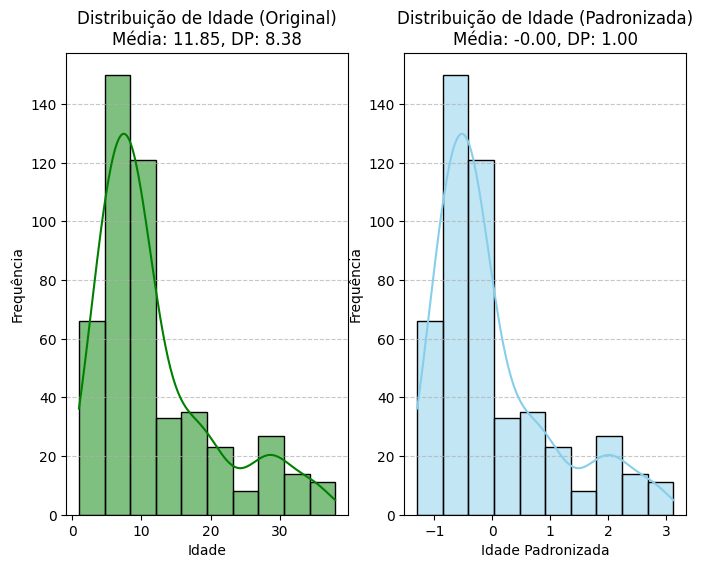

In [24]:
# Mostra a comparação da distribuição da variável IDADE antes e depois da padronização
plt.figure(figsize=(8, 6))

# Distribuição ANTES da Padronização
plt.subplot(1, 2, 1)
sns.histplot(idade_original, kde=True, bins=10, color='green')
plt.title(f'Distribuição de Idade (Original)\nMédia: {idade_original.mean():.2f}, DP: {idade_original.std():.2f}')
plt.xlabel('Idade')
plt.ylabel('Frequência')
# configra os eixos para exibir o eixo Y com tracejado
plt.grid(axis="y", linestyle="--", alpha=0.7)


# Distribuição DEPOIS da Padronização
plt.subplot(1, 2, 2)

# Passamos a Série 'IDADE' já padronizada de X_treino
sns.histplot(X_treino['IDADE'], kde=True, bins=10, color='skyblue')
plt.title(f'Distribuição de Idade (Padronizada)\nMédia: {X_treino["IDADE"].mean():.2f}, DP: {X_treino["IDADE"].std():.2f}')
plt.xlabel('Idade Padronizada')
plt.ylabel('Frequência')
# configra os eixos para exibir o eixo Y com tracejado
plt.grid(axis="y", linestyle="--", alpha=0.7)

Os gráficos mostram a distribuição da variável **IDADE** antes e depois da padronização. Nos dados originais, a **IDADE** possui média de 11,85 e desvio padrão de 8,38, mantendo sua escala real. Após a padronização, os valores são transformados para terem média próxima de 0 e desvio padrão igual a 1, sem alterar o formato da distribuição. Ou seja, a padronização apenas muda a escala dos dados, facilitando comparações e o uso em modelos de *Machine Learnig*, mas preserva suas características originais.

# 5- Conclusão
---

O projeto consistiu na aplicação de técnicas de análise de dados e boas práticas a um conjunto de dados contendo informações sobre paradas programadas de plataformas petrolíferas, com o objetivo de predizer a duração desses eventos. Para isso, foram realizadas etapas de análise exploratória e pré-processamento dos dados.

Essas etapas proporcionaram diversos *insights* relevantes. As visualizações e análises estatísticas evidenciaram correlações importantes e se mostraram eficazes na validação das hipóteses levantadas. Observou-se uma predominância de paradas de curta duração, acompanhada pela presença de eventos significativamente mais longos.

Durante a análise exploratória, não foram identificados problemas de qualidade no conjunto de dados, como valores ausentes ou registros duplicados. Foram observados alguns *outlier*s, os quais não indicam erros de medição ou digitação, mas sim observações válidas e potencialmente informativas para o modelo de predição.

Na etapa de pré-processamento, foram aplicadas técnicas como transformação e padronização dos dados, visando garantir que o modelo fosse capaz de aprender de forma eficiente as relações presentes no conjunto de dados.

As hipóteses propostas foram analisadas com sucesso, conforme descrito a seguir:

1. **Determinados tipos de plataformas estão associados a paradas programadas de maior duração?** *Sim. Observou-se que o tipo de plataforma está associado tanto à duração média quanto à variabilidade das operações. Plataformas fixas, FPU e SS apresentam maiores tempos de parada e maior incerteza, enquanto plataformas do tipo TLWP tendem a apresentar operações mais curtas e consistentes.*

2. **Existe correlação entre a idade da plataforma e a duração da parada programada?** *Não. O coeficiente de correlação obtido foi de 0,24, indicando uma relação linear positiva fraca entre a idade da plataforma e a duração das paradas. Isso sugere que plataformas mais antigas tendem, em média, a apresentar paradas ligeiramente mais longas, embora o efeito seja pouco expressivo.*

3. **Paradas em plataformas afretadas apresentam menor duração do que em plataformas próprias?** *Sim. Foram observados indícios de que a propriedade da plataforma está associada à duração das operações, com valores ligeiramente superiores em plataformas próprias.*

4. **Paradas em lâminas d’água rasas apresentam menor duração?** *Não. Os resultados indicam que operações em lâminas d’água profunda possuem a maiores durações típicas, a maior variabilidade e ocorrência de eventos extremos, e águas ultraprofundas a menores durações e maior estabilidade. Operações em lâminas d'água rasa apresentam mediana e variabilidade intermediárias entre as categorias.*

5. **O tipo de operação e a restrição à queima de gás influenciam a duração das paradas?** *Não foram observadas diferenças significativas na mediana entre os tipos de operação (produção e injeção). No entanto, operações de produção apresentam maior dispersão e maior presença de valores extremos, indicando maior variabilidade. Em relação à restrição à queima de gás, operações sem restrição tendem a apresentar maior duração e maior variabilidade, enquanto aquelas com restrição são, em geral, mais curtas e consistentes.*

**Próximos passos**:

Em todas as categorias analisadas, observou-se assimetria à direita, indicando a predominância de paradas de curta duração, com a presença de eventos significativamente mais longos. Esse comportamento pode ser explicado, em parte, pelo fato de a base de dados utilizada neste trabalho ser relativamente pequena, uma vez que paradas programadas ocorrem, em geral, apenas uma vez por ano.

Adicionalmente, uma parcela relevante do histórico desses eventos está associada a plataformas já desinvestidas ou em processo de descomissionamento. Esses registros foram excluídos da análise, a fim de evitar a introdução de vieses e garantir maior consistência nos resultados obtidos.

Cabe destacar que esta mesma base de dados também foi empregada no MVP desenvolvido na disciplina de *Machine Learning*.

Diante desse contexto, destacam-se duas principais ações para o aprimoramento do modelo:

1. Ampliação da base de dados, por meio da incorporação contínua de novas paradas programadas, à medida que ocorram, permitindo aumentar a variabilidade e a representatividade dos dados.

2. Integração dos trabalhos desenvolvidos, com a consolidação deste estudo e do MVP de *Machine Learning*, de forma a aplicar o dataset final deste trabalho aos modelos previamente construídos, resultando em um projeto mais robusto e completo.

